# Teste do Pipeline Multi-Source — Noticias de Hoje

Este notebook testa a coleta de noticias de ITUB4 de **todas as 3 fontes** disponiveis:
1. **InfoMoney** — artigos completos via WordPress API
2. **CVM Fatos Relevantes** — comunicados oficiais
3. **Google News** — agregador (Valor, Reuters, Bloomberg, Exame, etc.)

Apos coletar, roda o FinBERT-PT-BR para analise de sentimento e gera as mesmas metricas do pipeline existente.

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

sys.path.insert(0, '.')
sys.path.insert(0, '..')
sys.path.insert(0, '../1.news')

print(f"Data de hoje: {datetime.now().strftime('%Y-%m-%d')}")
print("Modulos carregados")

Data de hoje: 2026-03-29
Modulos carregados


## 1. Coleta de noticias — InfoMoney

Usa o mesmo extrator do Stage 1 para buscar artigos recentes sobre ITUB4.

In [2]:
import requests
from bs4 import BeautifulSoup
import re

def collect_infomoney_recent(ticker="ITUB4", max_articles=20):
    """Coleta artigos recentes do InfoMoney via WordPress REST API."""
    url = "https://www.infomoney.com.br/wp-json/wp/v2/posts"
    params = {
        "search": ticker,
        "per_page": max_articles,
        "orderby": "date",
        "order": "desc",
    }
    
    try:
        resp = requests.get(url, params=params, timeout=15)
        resp.raise_for_status()
        posts = resp.json()
    except Exception as e:
        print(f"Erro ao acessar InfoMoney: {e}")
        return []
    
    articles = []
    for post in posts:
        # Limpar HTML do conteudo
        title = BeautifulSoup(post.get("title", {}).get("rendered", ""), "html.parser").get_text()
        excerpt = BeautifulSoup(post.get("excerpt", {}).get("rendered", ""), "html.parser").get_text()
        content = BeautifulSoup(post.get("content", {}).get("rendered", ""), "html.parser").get_text()
        
        articles.append({
            "date": post.get("date", "")[:10],
            "title": title.strip(),
            "text": f"{title}. {excerpt}. {content}".strip()[:5000],
            "source": "InfoMoney",
            "link": post.get("link", ""),
        })
    
    print(f"InfoMoney: {len(articles)} artigos coletados")
    return articles

infomoney_articles = collect_infomoney_recent("ITUB4", max_articles=20)
for a in infomoney_articles[:3]:
    print(f"  [{a['date']}] {a['title'][:80]}...")

InfoMoney: 20 artigos coletados
  [2026-03-27] Ibovespa fecha em baixa seguindo o exterior, mas acumula ganho semanal de 3%...
  [2026-03-27] Ibovespa fecha em baixa, mas tem primeira semana positiva, depois de quatro nega...
  [2026-03-26] Ibovespa fecha em queda de 1,45% com dúvidas sobre desfecho no Oriente Médio...


## 2. Coleta de noticias — CVM Fatos Relevantes

Busca comunicados oficiais do Itau na CVM (ano atual).

In [3]:
from cvm_collector import download_year, filter_itau_fatos, fetch_document_text

current_year = datetime.now().year
print(f"Buscando Fatos Relevantes de {current_year}...")

df_cvm = download_year(current_year)
df_fatos = filter_itau_fatos(df_cvm)

cvm_articles = []
for _, row in df_fatos.iterrows():
    date_str = row.get("Data_Referencia", "") or row.get("Data_Entrega", "")
    try:
        date_iso = pd.to_datetime(date_str).strftime("%Y-%m-%d")
    except:
        date_iso = str(date_str)
    
    link = row.get("Link_Download", "")
    text = fetch_document_text(link) if link else ""
    
    cvm_articles.append({
        "date": date_iso,
        "title": f"Fato Relevante - {row.get('Categoria', '')}",
        "text": text[:5000] if text else "",
        "source": "CVM",
        "link": link,
    })

print(f"CVM: {len(cvm_articles)} fatos relevantes coletados")
for a in cvm_articles[:3]:
    print(f"  [{a['date']}] {a['title'][:80]}...")

2026-03-29 10:10:46 [INFO] Baixando dados de 2026: https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/IPE/DADOS/ipe_cia_aberta_2026.zip


Buscando Fatos Relevantes de 2026...


2026-03-29 10:10:46 [INFO]   Lendo arquivo: ipe_cia_aberta_2026.csv
2026-03-29 10:10:46 [INFO]   10979 registros carregados para 2026
2026-03-29 10:10:46 [INFO]   3 Fatos Relevantes do Itaú encontrados


CVM: 3 fatos relevantes coletados
  [2026-02-04] Fato Relevante - Fato Relevante...
  [2026-02-04] Fato Relevante - Fato Relevante...
  [2026-02-26] Fato Relevante - Fato Relevante...


## 3. Coleta de noticias — Google News

Busca noticias recentes sobre ITUB4 de multiplas fontes via Google News.

In [4]:
from google_news_collector import collect_gnews, collect_rss
from googlenewsdecoder import new_decoderv1
from newspaper import Article
from bs4 import BeautifulSoup
import re
import time

def clean_html(text):
    """Remove tags HTML e entidades, deixando so texto limpo."""
    if not text:
        return ""
    soup = BeautifulSoup(text, "html.parser")
    clean = soup.get_text(separator=" ", strip=True)
    clean = re.sub(r'&\w+;', ' ', clean)
    clean = re.sub(r'\s+', ' ', clean).strip()
    return clean

def extract_full_text(google_news_url):
    """
    Extrai texto completo de um artigo do Google News em 2 passos:
    1. Decodifica a URL do Google News para a URL real do site original
    2. Baixa e extrai o texto do site original com newspaper3k
    """
    # Passo 1: decodificar URL real
    try:
        result = new_decoderv1(google_news_url)
        if not result.get('status'):
            return None, None
        real_url = result['decoded_url']
    except Exception:
        return None, None
    
    # Passo 2: extrair texto do site original
    try:
        art = Article(real_url, language='pt')
        art.download()
        art.parse()
        if art.text and len(art.text) > 50:
            return art.text, real_url
    except Exception:
        pass
    
    return None, real_url

# Coletar via gnews (periodo curto para teste)
gn_articles_raw = []
for query in ["ITUB4"]:
    try:
        arts = collect_gnews(query, period="1d", max_results=20)
        gn_articles_raw.extend(arts)
    except Exception as e:
        print(f"Erro gnews '{query}': {e}")
    
    try:
        arts = collect_rss(query)
        gn_articles_raw.extend(arts)
    except Exception as e:
        print(f"Erro RSS '{query}': {e}")

# Deduplicar por URL
seen = set()
gn_unique = []
for a in gn_articles_raw:
    if a["link"] not in seen:
        seen.add(a["link"])
        gn_unique.append(a)

print(f"Google News: {len(gn_unique)} artigos unicos")
print(f"Extraindo texto completo (pode demorar ~1s por artigo)...\n")

# Extrair texto completo
gn_articles = []
success = 0
fail = 0
for i, a in enumerate(gn_unique):
    title = clean_html(a['title'])
    
    print(f"  [{i+1}/{len(gn_unique)}] {title[:60]}...", end=" ")
    full_text, real_url = extract_full_text(a["link"])
    
    if full_text:
        print(f"OK ({len(full_text)} chars)")
        success += 1
        text = full_text[:5000]
    else:
        print("FALHOU")
        fail += 1
        text = title  # so o titulo
    
    gn_articles.append({
        "date": a["date"],
        "title": title,
        "text": text,
        "source": a.get('publisher', a.get('source', 'Desconhecido')),
        "link": real_url or a["link"],
        "has_full_text": full_text is not None,
    })
    
    time.sleep(1.0)  # delay para nao ser bloqueado

print(f"\nResumo:")
print(f"  Texto completo: {success}/{len(gn_unique)} ({success/len(gn_unique)*100:.0f}%)")
print(f"  Apenas titulo:  {fail}/{len(gn_unique)} ({fail/len(gn_unique)*100:.0f}%)")

2026-03-29 10:11:16 [INFO] Coletando notícias via gnews: query='ITUB4', period=1d, max=20
2026-03-29 10:11:20 [INFO] gnews retornou 4 notícias para 'ITUB4'
2026-03-29 10:11:20 [INFO] Coletando notícias via RSS: query='ITUB4'
2026-03-29 10:11:21 [INFO] RSS retornou 100 notícias para 'ITUB4'


Google News: 104 artigos unicos
Extraindo texto completo (pode demorar ~1s por artigo)...

  [1/104] Dividendos em abril: Bradesco (BBDC4), Itaú (ITUB4), Iguatem... OK (4214 chars)
  [2/104] Fim da linha para o Itaucard: a reorganização societária do ... OK (1601 chars)
  [3/104] Incorporação do Itaucard avança e Itaú redesenha sua estrutu... OK (2910 chars)
  [4/104] Itaú: conselho aprova proposta de incorporação do Banco Itau... OK (1393 chars)
  [5/104] Dividendos em abril: Bradesco (BBDC4), Itaú (ITUB4), Iguatem... OK (4214 chars)
  [6/104] Fim da linha para o Itaucard: a reorganização societária do ... OK (1601 chars)
  [7/104] Por que o Itaú (ITUB4) caiu mais de 3% hoje? Ações de outros... OK (2460 chars)
  [8/104] Ibovespa e dólar hoje, Itaú (ITUB4), Copel (CPLE3) e mais: G... OK (2265 chars)
  [9/104] Itaú (ITUB4) anuncia reorganização societária e incorporação... OK (1433 chars)
  [10/104] Itaú (ITUB4) ou Itaúsa (ITSA4): Goldman dá veredito sobre me... OK (2134 chars)
  [11/10

## 4. Combinar todas as fontes

Junta todos os artigos e mostra um resumo por fonte.

In [5]:
all_articles = infomoney_articles + cvm_articles + gn_articles

print(f"{'='*60}")
print(f"TOTAL: {len(all_articles)} artigos de todas as fontes")
print(f"{'='*60}")
print(f"  InfoMoney:    {len(infomoney_articles)}")
print(f"  CVM:          {len(cvm_articles)}")
print(f"  Google News:  {len(gn_articles)}")

# Resumo por data
df_all = pd.DataFrame(all_articles)
df_all['date'] = pd.to_datetime(df_all['date'], errors='coerce')
print(f"{'='*60}")
print(f"Periodo: {df_all['date'].min().date()} a {df_all['date'].max().date()}")
print(f"{'='*60}")
print(f"Artigos por fonte:")
display(df_all['source'].value_counts().head(10))

TOTAL: 127 artigos de todas as fontes
  InfoMoney:    20
  CVM:          3
  Google News:  104
Periodo: 2025-08-06 a 2026-03-29
Artigos por fonte:


source
InfoMoney               34
Investidor10            18
suno.com.br             15
Valor Investe           12
Estadão E-Investidor     8
investalk.bb.com.br      8
Empiricus                4
Money Times              4
Seu Dinheiro             3
CVM                      3
Name: count, dtype: int64

In [6]:
df_all = pd.read_json("all_articles_with_sentiment.json", orient="records")
df_all.head()

,date,title,text,source,link,sentiment_class,sentiment,sentiment_logits,has_full_text
0,2026-03-27,"Ibovespa fecha em baixa seguindo o exterior, m...","Ibovespa fecha em baixa seguindo o exterior, m...",InfoMoney,https://www.infomoney.com.br/mercados/ibovespa...,1,NEGATIVE,"[-1.677518963813781, 1.5115851163864131, -1.80...",NaN
1,2026-03-27,"Ibovespa fecha em baixa, mas tem primeira sema...","Ibovespa fecha em baixa, mas tem primeira sema...",InfoMoney,https://www.infomoney.com.br/mercados/ibovespa...,1,NEGATIVE,"[-1.8123723268508911, 1.637385487556457, -1.61...",NaN
2,2026-03-26,"Ibovespa fecha em queda de 1,45% com dúvidas s...","Ibovespa fecha em queda de 1,45% com dúvidas s...",InfoMoney,https://www.infomoney.com.br/mercados/ibovespa...,1,NEGATIVE,"[-1.6884099245071411, 1.776560425758361, -1.74...",NaN
3,2026-03-26,"Ibovespa fecha com baixa robusta, em dia de IP...","Ibovespa fecha com baixa robusta, em dia de IP...",InfoMoney,https://www.infomoney.com.br/mercados/ibovespa...,1,NEGATIVE,"[-1.8512964248657222, 1.74096405506134, -1.658...",NaN
4,2026-03-25,Ibovespa sobe com investidor atento a negociaç...,Ibovespa sobe com investidor atento a negociaç...,InfoMoney,https://www.infomoney.com.br/mercados/ibovespa...,0,POSITIVE,"[-0.030634306371212002, -0.965076208114624, -1...",NaN


## 5. Analise de sentimento — FinBERT-PT-BR

Roda o mesmo modelo FinBERT usado nos stages anteriores em TODOS os artigos coletados.

In [7]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification

model_dir = '../4.finbert-br/FinBERT-PT-BR'
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = BertForSequenceClassification.from_pretrained(model_dir)
model.eval()

LABEL_MAP = {0: 'POSITIVE', 1: 'NEGATIVE', 2: 'NEUTRAL'}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'FinBERT carregado no device: {device}')

/home/takeo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13697.97it/s]
BertForSequenceClassification LOAD REPORT from: ../4.finbert-br/FinBERT-PT-BR
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT carregado no device: cuda


In [8]:
def predict_batch(texts, batch_size=16):
    """Analisa sentimento de um lote de textos com FinBERT."""
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Truncar textos muito longos
        batch = [t[:512] if t else "" for t in batch]
        
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=512).to(device)
        with torch.no_grad():
            logits = model(**tokens).logits.cpu().numpy()
        
        for log in logits:
            cls = int(np.argmax(log))
            results.append({
                'sentiment_class': cls,
                'sentiment': LABEL_MAP[cls],
                'logits': log.tolist(),
            })
    return results

# Preparar textos (titulo + texto disponivel)
texts = []
for a in all_articles:
    t = a.get('text', '') or a.get('title', '')
    texts.append(t[:1000])  # limitar para nao estourar memoria

print(f"Analisando sentimento de {len(texts)} artigos...")
sentiments = predict_batch(texts)

# Adicionar sentimento aos artigos
for art, sent in zip(all_articles, sentiments):
    art['sentiment_class'] = sent['sentiment_class']
    art['sentiment'] = sent['sentiment']
    art['sentiment_logits'] = sent['logits']

# Resumo
from collections import Counter
sent_counts = Counter(s['sentiment'] for s in sentiments)
print(f"Distribuicao de sentimento:")
for label, count in sent_counts.most_common():
    print(f"  {label}: {count} ({count/len(sentiments)*100:.1f}%)")

Analisando sentimento de 127 artigos...
Distribuicao de sentimento:
  POSITIVE: 63 (49.6%)
  NEUTRAL: 36 (28.3%)
  NEGATIVE: 28 (22.0%)


## 6. Agregacao diaria de sentimento

Gera as mesmas metricas do pipeline existente:
- : quantidade de artigos no dia
- : media do logit positivo
- : media do logit negativo  
- : media do logit neutro
- : media da classe de sentimento (0=pos, 1=neg, 2=neu)

Estas sao as features que alimentam os modelos de previsao.

In [9]:
# Criar DataFrame com sentimento por artigo
df_sent = pd.DataFrame([{
    'date': a['date'],
    'source': a['source'],
    'sentiment_class': a['sentiment_class'],
    'logit_pos': a['sentiment_logits'][0],
    'logit_neg': a['sentiment_logits'][1],
    'logit_neu': a['sentiment_logits'][2],
} for a in all_articles])

df_sent['date'] = pd.to_datetime(df_sent['date'], errors='coerce')
df_sent = df_sent.dropna(subset=['date'])

# Agregacao diaria (mesma logica do Stage 6)
daily = df_sent.groupby('date').agg(
    n_articles=('sentiment_class', 'count'),
    mean_logit_pos=('logit_pos', 'mean'),
    mean_logit_neg=('logit_neg', 'mean'),
    mean_logit_neu=('logit_neu', 'mean'),
    mean_sentiment=('sentiment_class', 'mean'),
).sort_index()

print(f"Sentimento diario agregado: {len(daily)} dias")
print(f"Ultimos 10 dias:")
display(daily.tail(10))

Sentimento diario agregado: 54 dias
Ultimos 10 dias:


,n_articles,mean_logit_pos,mean_logit_neg,mean_logit_neu,mean_sentiment
date,,,,,
2026-03-19,5,-0.369877,-1.333156,-0.476827,1.000000
2026-03-20,4,-1.728438,0.774424,-1.027218,1.250000
2026-03-21,1,-1.827993,1.657100,-1.682925,1.000000
2026-03-23,1,-0.712231,-1.380311,-0.591287,2.000000
2026-03-24,4,0.082726,-1.221228,-1.154712,0.250000
2026-03-25,3,0.057745,-0.999479,-1.437722,0.333333
2026-03-26,3,-1.605026,0.733688,-1.011328,1.333333
2026-03-27,4,-1.451233,0.628119,-1.197041,1.250000
2026-03-28,4,-0.561075,-1.463410,-0.332763,1.500000


## 7. Comparacao: sentimento por fonte

Compara o sentimento medio de cada fonte para ver se ha diferencas sistematicas.

In [11]:
# Agregacao por fonte
source_summary = df_sent.groupby('source').agg(
    n_articles=('sentiment_class', 'count'),
    mean_logit_pos=('logit_pos', 'mean'),
    mean_logit_neg=('logit_neg', 'mean'),
    mean_logit_neu=('logit_neu', 'mean'),
    mean_sentiment=('sentiment_class', 'mean'),
    pct_positive=('sentiment_class', lambda x: (x == 0).mean()),
    pct_negative=('sentiment_class', lambda x: (x == 1).mean()),
    pct_neutral=('sentiment_class', lambda x: (x == 2).mean()),
).round(3)

print("Sentimento medio por fonte:")
display(source_summary)

Sentimento medio por fonte:


,n_articles,mean_logit_pos,mean_logit_neg,mean_logit_neu,mean_sentiment,pct_positive,pct_negative,pct_neutral
source,,,,,,,,
ADVFN,2,-0.180,-1.583,-0.627,1.000,0.500,0.000,0.500
CVM,3,-1.399,-0.353,-0.394,1.667,0.000,0.333,0.667
Economic News Brasil,1,1.232,-1.964,-1.270,0.000,1.000,0.000,0.000
Empiricus,4,-0.915,-1.828,0.587,1.500,0.250,0.000,0.750
Estadão E-Investidor,8,0.266,-0.969,-1.188,0.750,0.500,0.250,0.250
Genial Analisa,3,1.827,-1.693,-1.725,0.000,1.000,0.000,0.000
Guia do Investidor,1,-1.275,-1.316,0.369,2.000,0.000,0.000,1.000
InfoMoney,34,-0.292,-0.442,-1.377,0.588,0.471,0.471,0.059
Investidor10,18,-0.066,-1.132,-0.903,0.667,0.556,0.222,0.222


## 8. Visualizacao

Graficos do sentimento coletado.

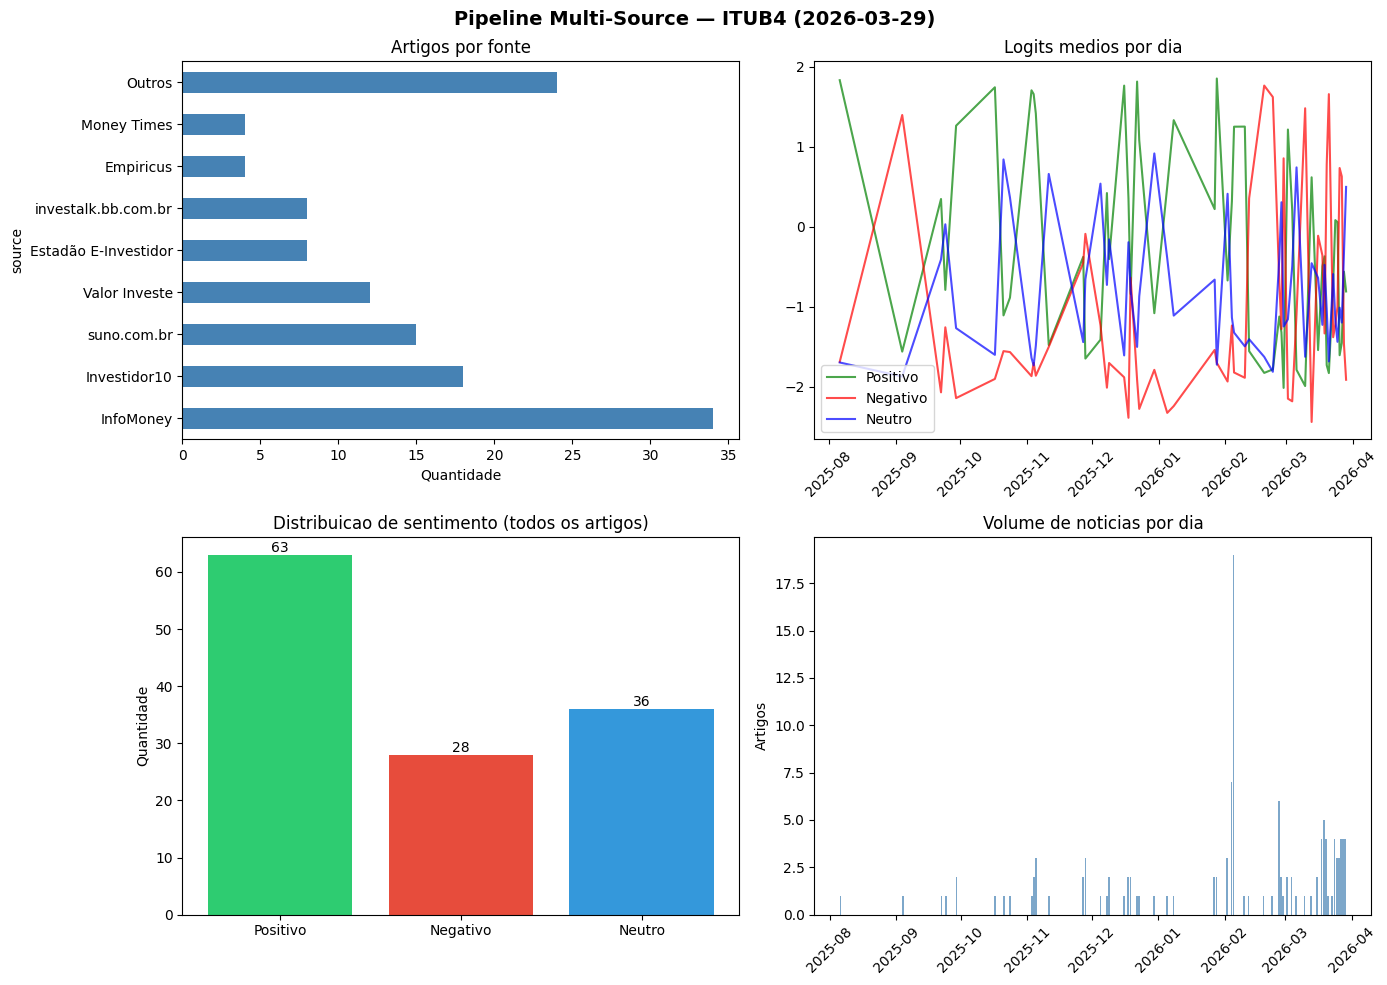

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Pipeline Multi-Source — ITUB4 ({datetime.now().strftime("%Y-%m-%d")})', 
             fontsize=14, fontweight='bold')

# 1. Artigos por fonte
ax = axes[0, 0]
source_counts = df_sent['source'].value_counts()
# Agrupar fontes pequenas
top_sources = source_counts.head(8)
if len(source_counts) > 8:
    top_sources['Outros'] = source_counts.iloc[8:].sum()
top_sources.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Artigos por fonte')
ax.set_xlabel('Quantidade')

# 2. Sentimento por dia
ax = axes[0, 1]
if len(daily) > 1:
    ax.plot(daily.index, daily['mean_logit_pos'], 'g-', label='Positivo', alpha=0.7)
    ax.plot(daily.index, daily['mean_logit_neg'], 'r-', label='Negativo', alpha=0.7)
    ax.plot(daily.index, daily['mean_logit_neu'], 'b-', label='Neutro', alpha=0.7)
    ax.legend()
    ax.set_title('Logits medios por dia')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
else:
    ax.bar(['Positivo', 'Negativo', 'Neutro'], 
           [daily['mean_logit_pos'].iloc[0], daily['mean_logit_neg'].iloc[0], daily['mean_logit_neu'].iloc[0]],
           color=['green', 'red', 'blue'])
    ax.set_title('Logits medios (dia unico)')

# 3. Distribuicao de sentimento
ax = axes[1, 0]
sent_dist = df_sent['sentiment_class'].value_counts().sort_index()
labels = ['Positivo', 'Negativo', 'Neutro']
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar([labels[i] for i in sent_dist.index], sent_dist.values, color=[colors[i] for i in sent_dist.index])
ax.set_title('Distribuicao de sentimento (todos os artigos)')
ax.set_ylabel('Quantidade')
for bar, val in zip(bars, sent_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')

# 4. Artigos por dia
ax = axes[1, 1]
if len(daily) > 1:
    ax.bar(daily.index, daily['n_articles'], color='steelblue', alpha=0.7)
    ax.set_title('Volume de noticias por dia')
    ax.set_ylabel('Artigos')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
else:
    ax.bar(['Hoje'], [daily['n_articles'].iloc[0]], color='steelblue')
    ax.set_title(f'Artigos hoje: {daily["n_articles"].iloc[0]}')

plt.tight_layout()
plt.savefig('results/test_pipeline_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Formato de saida — compativel com o pipeline existente

O DataFrame  tem o mesmo formato usado nos Stages 4 e 6 como input dos modelos.
Pode ser salvo como CSV e usado diretamente no Stage 7 para retreinar modelos com dados multi-source.

In [19]:
# Salvar sentimento diario
daily.to_csv('multi_source_daily_sentiment.csv')
print(f"Sentimento diario salvo em multi_source_daily_sentiment.csv")
print(f"Formato: {daily.columns.tolist()}")
print(f"Shape: {daily.shape}")

# Salvar artigos completos com sentimento
with open('all_articles_with_sentiment.json', 'w', encoding='utf-8') as f:
    for a in all_articles:
        if isinstance(a.get('date'), pd.Timestamp):
            a['date'] = a['date'].strftime('%Y-%m-%d')
    json.dump(all_articles, f, ensure_ascii=False, indent=2, default=str)

print(f"Artigos com sentimento salvos em all_articles_with_sentiment.json ({len(all_articles)} artigos)")
print("="*60)
print("Pipeline multi-source testado com sucesso!")
print("="*60)

Sentimento diario salvo em multi_source_daily_sentiment.csv
Formato: ['n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']
Shape: (54, 5)
Artigos com sentimento salvos em all_articles_with_sentiment.json (127 artigos)
Pipeline multi-source testado com sucesso!


## 10. Visualizacao dos vetores semanticos

Tres formas de visualizar os vetores de sentimento (logit_pos, logit_neg, logit_neu) de cada artigo:
1. **Scatter 3D** — plota os 3 logits diretamente em 3 eixos
2. **t-SNE** — reduz os 3 logits para 2D preservando distancias locais
3. **Distancia entre fontes** — compara quao diferentes sao os vetores de sentimento de cada fonte

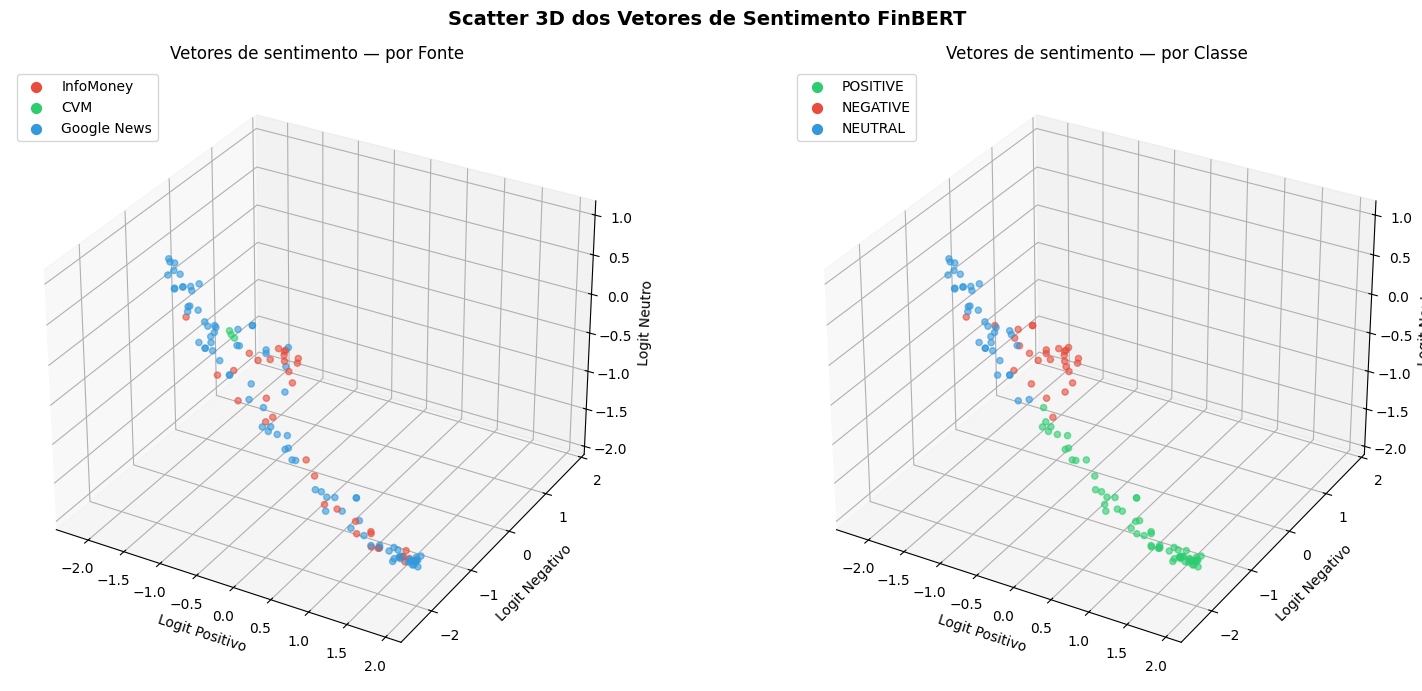

Cada ponto e um artigo. Artigos proximos no espaco 3D tem sentimento similar.
Se as cores (fontes) formam clusters separados, as fontes tem vieses diferentes.


In [22]:
# === SCATTER 3D: Logits de sentimento por fonte ===
# Cada artigo e um ponto no espaco 3D (pos, neg, neu).
# Artigos com sentimento similar ficam proximos.

from mpl_toolkits.mplot3d import Axes3D

# Preparar dados
logits = np.array([a['sentiment_logits'] for a in all_articles])

# Mapear fontes para categorias simplificadas
def simplify_source(s):
    if 'InfoMoney' in s and 'Google' not in s:
        return 'InfoMoney'
    elif 'CVM' in s:
        return 'CVM'
    else:
        return 'Google News'

source_labels = [simplify_source(a['source']) for a in all_articles]
sentiment_labels = [a['sentiment'] for a in all_articles]

# Cores por fonte
source_colors = {'InfoMoney': '#e74c3c', 'CVM': '#2ecc71', 'Google News': '#3498db'}
colors_by_source = [source_colors[s] for s in source_labels]

# Cores por sentimento
sent_colors = {'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c', 'NEUTRAL': '#3498db'}
colors_by_sent = [sent_colors[s] for s in sentiment_labels]

fig = plt.figure(figsize=(16, 7))

# 3D por fonte
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(logits[:, 0], logits[:, 1], logits[:, 2], 
            c=colors_by_source, alpha=0.6, s=20)
ax1.set_xlabel('Logit Positivo')
ax1.set_ylabel('Logit Negativo')
ax1.set_zlabel('Logit Neutro')
ax1.set_title('Vetores de sentimento — por Fonte')
# Legenda manual
for name, color in source_colors.items():
    ax1.scatter([], [], [], c=color, label=name, s=50)
ax1.legend(loc='upper left')

# 3D por sentimento
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(logits[:, 0], logits[:, 1], logits[:, 2], 
            c=colors_by_sent, alpha=0.6, s=20)
ax2.set_xlabel('Logit Positivo')
ax2.set_ylabel('Logit Negativo')
ax2.set_zlabel('Logit Neutro')
ax2.set_title('Vetores de sentimento — por Classe')
for name, color in sent_colors.items():
    ax2.scatter([], [], [], c=color, label=name, s=50)
ax2.legend(loc='upper left')

plt.suptitle('Scatter 3D dos Vetores de Sentimento FinBERT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/scatter3d_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cada ponto e um artigo. Artigos proximos no espaco 3D tem sentimento similar.")
print(f"Se as cores (fontes) formam clusters separados, as fontes tem vieses diferentes.")

### t-SNE: Reducao de dimensionalidade

O t-SNE pega os 3 numeros de cada artigo (logit positivo, negativo, neutro) e encontra a melhor forma de representar esses pontos em 2D, preservando as distancias relativas. Artigos com sentimento parecido ficam juntos, artigos com sentimento diferente ficam longe.

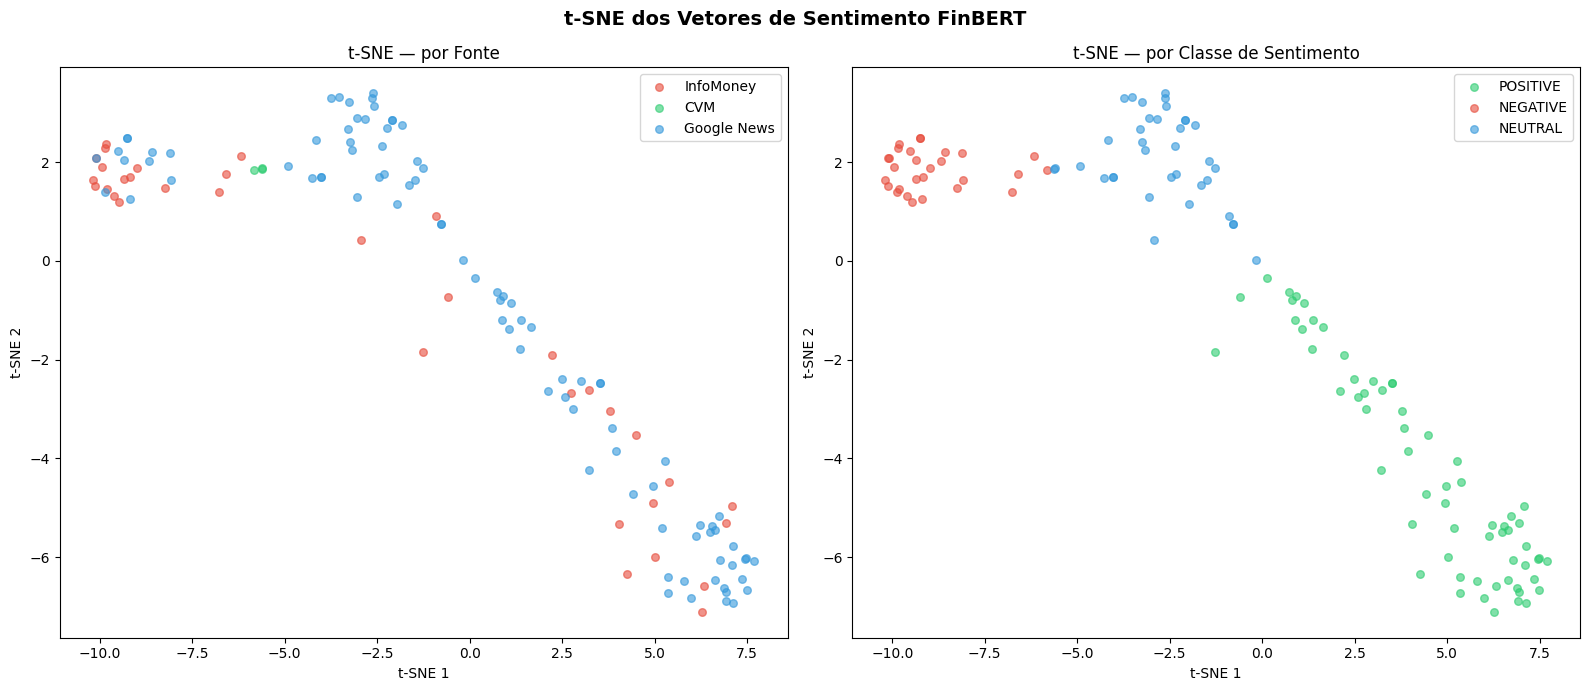

Se as cores formam grupos separados, o modelo distingue bem as classes.
Se as cores se misturam, os artigos tem sentimento ambiguo.


In [24]:
# === t-SNE: Reducao para 2D ===
from sklearn.manifold import TSNE

# Rodar t-SNE nos logits (3D -> 2D)
# perplexity deve ser menor que n_samples
perp = min(30, len(logits) - 1)
tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
logits_2d = tsne.fit_transform(logits)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# t-SNE por fonte
ax = axes[0]
for name, color in source_colors.items():
    mask = [s == name for s in source_labels]
    ax.scatter(logits_2d[mask, 0], logits_2d[mask, 1], 
               c=color, label=name, alpha=0.6, s=30)
ax.set_title('t-SNE — por Fonte')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()

# t-SNE por sentimento
ax = axes[1]
for name, color in sent_colors.items():
    mask = [s == name for s in sentiment_labels]
    ax.scatter(logits_2d[mask, 0], logits_2d[mask, 1], 
               c=color, label=name, alpha=0.6, s=30)
ax.set_title('t-SNE — por Classe de Sentimento')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()

plt.suptitle('t-SNE dos Vetores de Sentimento FinBERT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/tsne_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Se as cores formam grupos separados, o modelo distingue bem as classes.")
print("Se as cores se misturam, os artigos tem sentimento ambiguo.")

### Distancia entre fontes

Calcula a distancia media entre os vetores de sentimento de cada par de fontes. Se a distancia entre InfoMoney e CVM e grande, significa que essas fontes produzem sentimentos sistematicamente diferentes — o que e informacao util para os modelos.

Centroides de sentimento por fonte:
Fonte            Logit Pos  Logit Neg  Logit Neu  N artigos
---------------------------------------------------------
InfoMoney           -0.292     -0.442     -1.377         34
CVM                 -1.399     -0.353     -0.394          3
Google News          0.017     -1.414     -0.681         90

Distancia media entre fontes (euclidiana):


,CVM,Google News,InfoMoney
CVM,0.063,2.506,2.532
Google News,2.506,2.386,2.831
InfoMoney,2.532,2.831,2.608


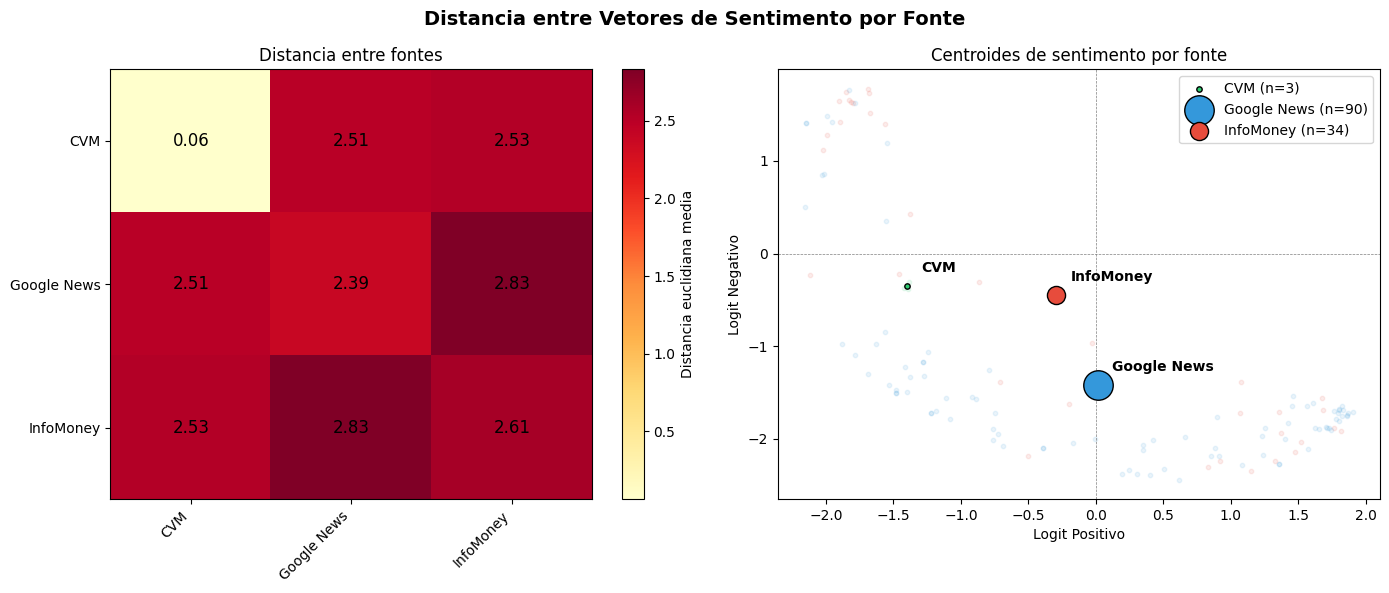


Interpretacao:
- Distancia alta entre fontes = sentimentos sistematicamente diferentes
- Distancia baixa = fontes concordam no sentimento
- O tamanho do circulo no grafico de centroides e proporcional ao numero de artigos


In [26]:
# === DISTANCIA ENTRE FONTES ===
from scipy.spatial.distance import cdist

# Agrupar logits por fonte simplificada
source_groups = {}
for art, src in zip(all_articles, source_labels):
    if src not in source_groups:
        source_groups[src] = []
    source_groups[src].append(art['sentiment_logits'])

# Calcular centroide (media dos vetores) de cada fonte
centroids = {}
for src, vecs in source_groups.items():
    centroids[src] = np.mean(vecs, axis=0)

print("Centroides de sentimento por fonte:")
print(f"{'Fonte':<15} {'Logit Pos':>10} {'Logit Neg':>10} {'Logit Neu':>10} {'N artigos':>10}")
print("-" * 57)
for src in ['InfoMoney', 'CVM', 'Google News']:
    if src in centroids:
        c = centroids[src]
        n = len(source_groups[src])
        print(f"{src:<15} {c[0]:>10.3f} {c[1]:>10.3f} {c[2]:>10.3f} {n:>10}")

# Matriz de distancia entre fontes
source_names = sorted(source_groups.keys())
n_sources = len(source_names)
dist_matrix = np.zeros((n_sources, n_sources))

for i, s1 in enumerate(source_names):
    for j, s2 in enumerate(source_names):
        # Distancia euclidiana media entre todos os pares de artigos
        d = cdist(source_groups[s1], source_groups[s2], metric='euclidean')
        dist_matrix[i, j] = d.mean()

print(f"\nDistancia media entre fontes (euclidiana):")
df_dist = pd.DataFrame(dist_matrix, index=source_names, columns=source_names).round(3)
display(df_dist)

# Visualizacao: heatmap de distancia + centroides 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap de distancia
ax = axes[0]
im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n_sources))
ax.set_yticks(range(n_sources))
ax.set_xticklabels(source_names, rotation=45, ha='right')
ax.set_yticklabels(source_names)
# Valores nas celulas
for i in range(n_sources):
    for j in range(n_sources):
        ax.text(j, i, f'{dist_matrix[i,j]:.2f}', ha='center', va='center', fontsize=12)
plt.colorbar(im, ax=ax, label='Distancia euclidiana media')
ax.set_title('Distancia entre fontes')

# Centroides em 2D (pos vs neg)
ax = axes[1]
for src in source_names:
    c = centroids[src]
    color = source_colors.get(src, 'gray')
    n = len(source_groups[src])
    ax.scatter(c[0], c[1], c=color, s=n*5, label=f'{src} (n={n})', 
               edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(src, (c[0], c[1]), textcoords="offset points", 
                xytext=(10, 10), fontsize=10, fontweight='bold')

# Plotar todos os pontos tambem (transparentes)
for art, src in zip(all_articles, source_labels):
    l = art['sentiment_logits']
    color = source_colors.get(src, 'gray')
    ax.scatter(l[0], l[1], c=color, alpha=0.1, s=10)

ax.set_xlabel('Logit Positivo')
ax.set_ylabel('Logit Negativo')
ax.set_title('Centroides de sentimento por fonte')
ax.legend(loc='best')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('Distancia entre Vetores de Sentimento por Fonte', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/source_distances.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretacao:")
print("- Distancia alta entre fontes = sentimentos sistematicamente diferentes")
print("- Distancia baixa = fontes concordam no sentimento")
print("- O tamanho do circulo no grafico de centroides e proporcional ao numero de artigos")

### Scatter 2D: Pares de logits

Plota cada par de dimensoes (pos vs neg, pos vs neu, neg vs neu) para ver as relacoes entre as componentes do vetor de sentimento.

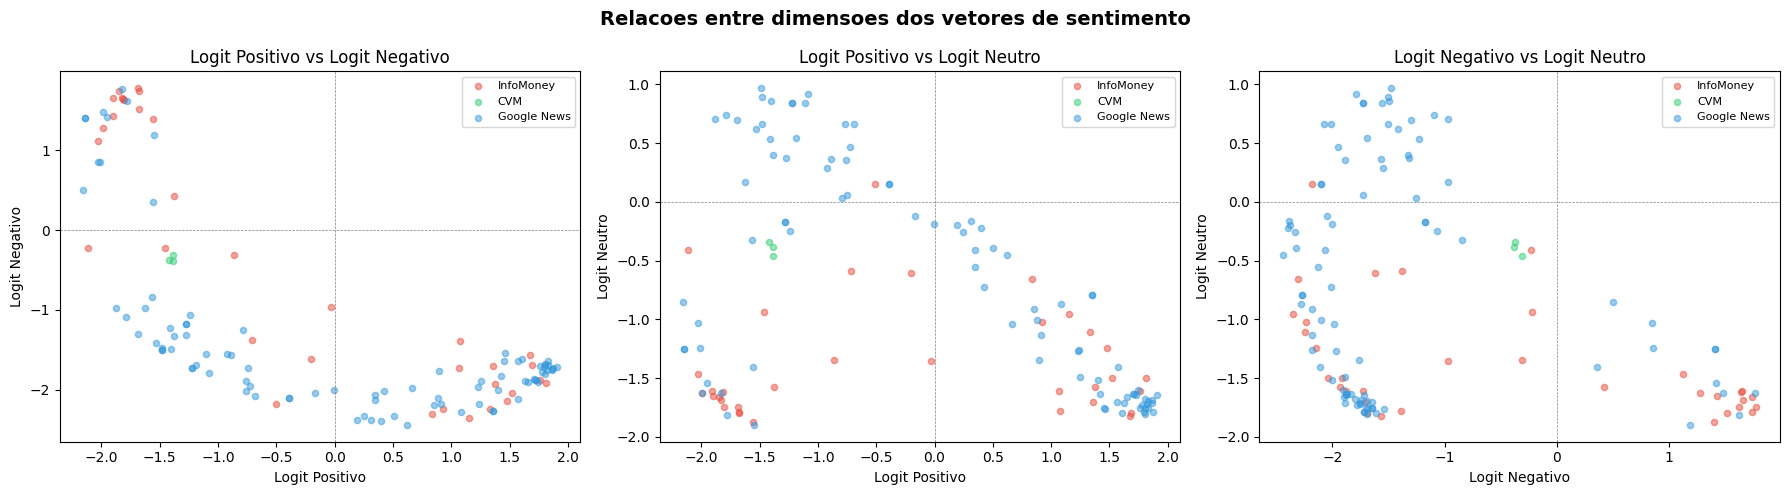

Pos vs Neg: se ha correlacao negativa, artigos positivos tendem a nao ser negativos (esperado)
Pos vs Neu: relacao entre positividade e neutralidade
Neg vs Neu: relacao entre negatividade e neutralidade


In [27]:
# === SCATTER 2D: Pares de logits ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    (0, 1, 'Logit Positivo', 'Logit Negativo'),
    (0, 2, 'Logit Positivo', 'Logit Neutro'),
    (1, 2, 'Logit Negativo', 'Logit Neutro'),
]

for ax, (i, j, xlabel, ylabel) in zip(axes, pairs):
    for name, color in source_colors.items():
        mask = [s == name for s in source_labels]
        ax.scatter(logits[mask, i], logits[mask, j], 
                   c=color, label=name, alpha=0.5, s=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}')
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('Relacoes entre dimensoes dos vetores de sentimento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/pairwise_logits.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pos vs Neg: se ha correlacao negativa, artigos positivos tendem a nao ser negativos (esperado)")
print("Pos vs Neu: relacao entre positividade e neutralidade")
print("Neg vs Neu: relacao entre negatividade e neutralidade")